In [1]:
"https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"

'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv", sep="\t")
df.sample(5)

,order_id,quantity,item_name,choice_description,item_price
1947,787,1,Carnitas Burrito,"[[Fresh Tomato Salsa (Mild), Roasted Chili Cor...",$8.99
1559,633,3,Canned Soft Drink,[Coke],$3.75
3892,1560,1,Chicken Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",$8.75
4454,1775,1,Chicken Burrito,"[Tomatillo Red Chili Salsa, [Rice, Pinto Beans...",$8.75
959,394,1,Carnitas Burrito,"[Fresh Tomato Salsa, [Rice, Pinto Beans, Cheese]]",$9.25


## Basic DataFrame

Consider the following Python dictionary data and Python list labels:

```
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'],
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2],
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
```
```
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']
```

### `Q-1:`
i. Create a DataFrame birds from the above dictionary data which has the index labels.

ii. Display basic information about the dataFrame.

iii. Show Alternate rows of the dataframe.

In [4]:
# i

data = {
'birds': ['Cranes','Cranes','plovers','spoonbills','spoonbills','Cranes','plovers','Cranes','spoonbills','spoonbills','Cranes'],
'age': [3.5,4,1.5,np.nan,6,3,5.5,np.nan,8,4,3.5],
'visits':[2,4,3,4,3,4,2,2,3,2,2],
'priority':['yes','yes','no',np.nan,'no','no','no','yes','no','no','yes']
}

labels = ['a','b','c','d','e','f','g','h','i','j','k']

birds = pd.DataFrame(data, index=labels)

In [5]:
# ii

birds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, a to k
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   birds     11 non-null     object 
 1   age       9 non-null      float64
 2   visits    11 non-null     int64  
 3   priority  10 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 440.0+ bytes


In [6]:
# iii 

birds.iloc[::2]

,birds,age,visits,priority
a,Cranes,3.5,2,yes
c,plovers,1.5,3,no
e,spoonbills,6.0,3,no
g,plovers,5.5,2,no
i,spoonbills,8.0,3,no
k,Cranes,3.5,2,yes


### `Q-2:`
i. Show only rows [1st, 3rd, 7th] from columns ['bird', 'age']

ii. Select rows where the number of visits is less than 4.

In [7]:
# code here

# i
birds.loc[['a','c','g'], ['birds','age']]

# ii
birds[birds['visits'] < 4]

,birds,age,visits,priority
a,Cranes,3.5,2,yes
c,plovers,1.5,3,no
e,spoonbills,6.0,3,no
g,plovers,5.5,2,no
h,Cranes,NaN,2,yes
i,spoonbills,8.0,3,no
j,spoonbills,4.0,2,no
k,Cranes,3.5,2,yes


### `Q-3:`
i. Select all rows with nan values in age and visits column.

ii. Fill nan with respective series mode value.

In [8]:
# code here

# i
birds[birds[['age','visits']].isna().any(axis=1)]

# ii
birds['age'].fillna(birds['age'].mode()[0], inplace=True)
birds['visits'].fillna(birds['visits'].mode()[0], inplace=True)

### `Q-4`
i. Find the total number of visits of the bird Cranes

ii. Find the number of each type of birds in dataframe.

iii. Print no of duplicate rows

iv. Drop Duplicates rows and make this changes permanent. Show dataframe after changes.

In [9]:
# code here

# i. 

cranes_visits = birds[birds['birds'] == 'Cranes']['visits'].sum()
print(cranes_visits)

14


In [10]:
# ii. 

birds['birds'].value_counts()

birds
Cranes        5
spoonbills    4
plovers       2
Name: count, dtype: int64

In [11]:
# iii. 

print(birds.duplicated().sum())
print(birds[birds.duplicated()])

2
    birds  age  visits priority
h  Cranes  3.5       2      yes
k  Cranes  3.5       2      yes


In [12]:
# iv. 

birds.drop_duplicates(inplace=True)
print(birds)

        birds  age  visits priority
a      Cranes  3.5       2      yes
b      Cranes  4.0       4      yes
c     plovers  1.5       3       no
d  spoonbills  3.5       4      NaN
e  spoonbills  6.0       3       no
f      Cranes  3.0       4       no
g     plovers  5.5       2       no
i  spoonbills  8.0       3       no
j  spoonbills  4.0       2       no


## Question on IPL Data

IPL Data Link :  https://drive.google.com/file/d/1yKVUuexl6lIKuFQy7uIPgDgXhJ0L4SIg/view?usp=share_link

https://www.kaggle.com/datasets/vora1011/ipl-2008-to-2021-all-match-dataset?select=IPL_Matches_2008_2022.csv

Download ipl matches 2008-2022 file.

### `Q-5:` In IPL matches dataset some teams name has changed.
You will have to consider them as same.
```
'Delhi Capitals' formerly as 'Delhi Daredevils'
'Punjab Kings' formerly as 'Kings XI Punjab'
'Rising Pune Supergiant' formerly as 'Rising Pune Supergiants'
```
You need to make changes accordingly. Consider current name for each teams.

Be careful Gujrat Titans and Gujrat Lions are different teams.

In [13]:
# code here

ipl = pd.read_csv("datasets/IPL_Matches_2008_2022.csv")
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team2Players    

In [14]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}

cols = ['Team1', 'Team2', 'TossWinner', 'WinningTeam']

ipl[cols] = ipl[cols].replace(team_mapping)

### `Q-6` Write a code which can display the bar chart of top 5 teams who have played maximum number of matches in the IPL.
>  Hint: Be careful the data is divided in 2 different cols(Team 1 and Team 2)

In [15]:
ipl.sample(4)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
370,1082593,Rajkot,2017-04-07,2017,3,Gujarat Lions,Kolkata Knight Riders,Saurashtra Cricket Association Stadium,Kolkata Knight Riders,field,N,Kolkata Knight Riders,Wickets,10.0,NaN,CA Lynn,"['JJ Roy', 'BB McCullum', 'SK Raina', 'AJ Finc...","['G Gambhir', 'CA Lynn', 'RV Uthappa', 'MK Pan...",Nitin Menon,CK Nandan
667,548343,Chennai,2012-04-28,2012,37,Chennai Super Kings,Punjab Kings,"MA Chidambaram Stadium, Chepauk",Punjab Kings,bat,N,Punjab Kings,Runs,7.0,NaN,Mandeep Singh,"['F du Plessis', 'S Badrinath', 'SK Raina', 'W...","['Mandeep Singh', 'SE Marsh', 'Azhar Mahmood',...",BF Bowden,SK Tarapore
901,336033,Chennai,2008-05-24,2007/08,49,Chennai Super Kings,Rajasthan Royals,"MA Chidambaram Stadium, Chepauk",Rajasthan Royals,bat,N,Rajasthan Royals,Runs,10.0,NaN,JA Morkel,"['PA Patel', 'SP Fleming', 'SK Raina', 'JA Mor...","['GC Smith', 'SA Asnodkar', 'Kamran Akmal', 'Y...",DJ Harper,SL Shastri
474,829741,Ahmedabad,2015-04-21,2015,18,Rajasthan Royals,Punjab Kings,"Sardar Patel Stadium, Motera",Punjab Kings,field,Y,Punjab Kings,SuperOver,NaN,NaN,SE Marsh,"['AM Rahane', 'SR Watson', 'DJ Hooda', 'SPD Sm...","['M Vijay', 'V Sehwag', 'SE Marsh', 'GJ Maxwel...",M Erasmus,S Ravi


Mumbai Indians                 231
Royal Challengers Bangalore    226
Delhi Capitals                 224
Kolkata Knight Riders          223
Punjab Kings                   218
Name: count, dtype: int64


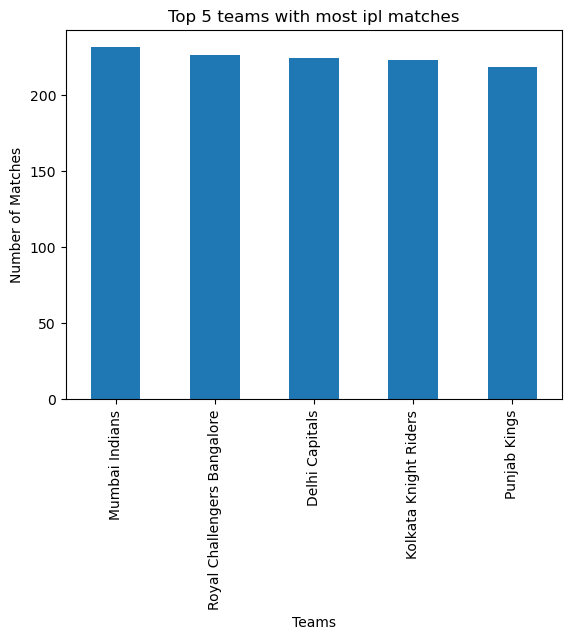

In [16]:
# code here

teams = pd.concat([ipl['Team1'], ipl['Team2']])
top_5 = teams.value_counts().head(5)
print(top_5)

top_5.plot(kind='bar', title="Top 5 teams with most ipl matches")

plt.xlabel("Teams")
plt.ylabel("Number of Matches")
plt.show()

### `Q-7:` Player who got Most no. of player of the match award playing against Mumbai Indians.
> Just for this question assume player of the match award is given to players from winning team. Although this is true in most of the cases.


In [17]:
# code here

mi_matches = ipl[(ipl['Team1'] == 'Mumbai Indians') | (ipl['Team2'] == 'Mumbai Indians')]
against_mi = mi_matches[mi_matches['WinningTeam'] != 'Mumbai Indians']

result = against_mi['Player_of_Match'].value_counts().idxmax()
print(result)

KL Rahul


### `Q-8:` Team1 vs Team2 Dashbord
Create a function which will take two string(name of two teams) as input. Show win Loss record between them and player getting most player of the match award in matches between these two teams.
```
team1_vs_team2('Kolkata Knight Riders','Chennai Super Kings')
```

In [18]:
# code here

def team1_vs_team2(team1, team2): 
    matches = ipl[
        ((ipl['Team1'] == team1) & (ipl['Team2'] == team2)) | 
        ((ipl['Team1'] == team2) & (ipl['Team2'] == team1))
    ]

    print("Total Matches : ", matches.shape[0])

    # win loss record 
    print("\n Win-Loss Record : ")
    print(matches['WinningTeam'].value_counts())

    # Player with most player of match awards
    print("\n Top player of the Match : ")
    print(matches['Player_of_Match'].value_counts().idxmax())

In [19]:
team1_vs_team2('Kolkata Knight Riders','Chennai Super Kings')

Total Matches :  26

 Win-Loss Record : 
WinningTeam
Chennai Super Kings      17
Kolkata Knight Riders     9
Name: count, dtype: int64

 Top player of the Match : 
RA Jadeja


### `Q-9:` Find out the top 7 cities where the matches of Kolkata Knight Riders are played frequently and plot the result as bar chart.

*`.plot(kind = "bar")` can help you to plot the bar chart. Also you can learn more about this method from [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)*



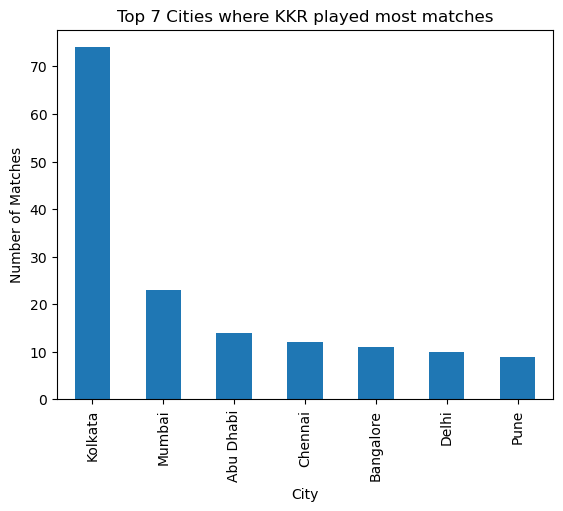

In [20]:
# code here

kkr_matches = ipl[(ipl['Team1'] == 'Kolkata Knight Riders') | 
                  (ipl['Team2'] == 'Kolkata Knight Riders')]

top_cities = kkr_matches['City'].value_counts().head(7)


top_cities.plot(kind='bar')

plt.title("Top 7 Cities where KKR played most matches")
plt.xlabel("City")
plt.ylabel("Number of Matches")
plt.show()


### `Q-10:` Find out the average margin for the team Mumbai Indians for only the session 2011.

In [21]:
# code here

mi_2011 = ipl[(ipl['Season'] == '2011') & (ipl['WinningTeam'] == 'Mumbai Indians')]

avg_margin = mi_2011['Margin'].mean()

print(avg_margin)

15.4
